# Exploratory Data Analysis: UCI Heart Disease Dataset
## 1. Project Overview


This notebook conducts an Exploratory Data Analysis (EDA) on the Cleveland Heart Disease Dataset. The goal is to analyze clinical and demographic features to understand the markers associated with cardiovascular disease. This dataset is a standard benchmark in medical machine learning, offering a mix of categorical, ordinal, and continuous physiological data.

### 1.1 Install Requirements

In [ ]:
# Dependencies: matplotlib, seaborn, pandas, numpy, ucimlrepo
# Install via: venv/bin/pip install matplotlib seaborn pandas numpy ucimlrepo

## 2. Fetch Data

This dataset contains 303 instances and 13 features, with a target variable num indicating the presence or absence of disease.

In [1]:
import pandas as pd

# Load from local CSV (already cleaned with mode imputation — original had 6 missing values in ca/thal)
# To re-fetch from UCI: from ucimlrepo import fetch_ucirepo; heart_disease = fetch_ucirepo(id=45)
df_raw = pd.read_csv('heart_disease_cleaned.csv')

X = df_raw.drop(columns=['num'])
y = df_raw[['num']]

print(f"Loaded {df_raw.shape[0]} rows × {df_raw.shape[1]} cols")
print(f"Features: {list(X.columns)}")
print(f"Target distribution:\n{y['num'].value_counts().sort_index()}")

Loaded 303 rows × 14 cols
Features: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Target distribution:
num
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64


## 3. Data Overview
Key clinical variables include:

- Vital Signs: trestbps (resting blood pressure), chol (serum cholesterol), and thalach (maximum heart rate).

- Cardiac Markers: oldpeak (ST depression induced by exercise) and slope (the slope of the peak exercise ST segment).

- Diagnostic Test Results: ca (number of major vessels colored by fluoroscopy) and thal (thalassemia diagnosis).

Target Distribution: The num target is graded, but for binary classification, we can treat 0 as "Healthy" and 1-4 as "Presence of Disease."

- No Heart Disease (num=0): 164 cases
- Heart Disease Present (num=1-4): 139 cases

In [2]:
import pandas as pd

# Show first few rows
print("Features (X) head:")
print(X.head())

print("\nTarget (y) head:")
print(y.head())

# Check shape
print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

# Check column names and types
print("\nColumn info:")
print(X.info())

# Check target distribution
print("\nTarget distribution:")
print(y.value_counts())


Features (X) head:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  
0  0.0   6.0  
1  3.0   3.0  
2  2.0   7.0  
3  0.0   3.0  
4  0.0   3.0  

Target (y) head:
   num
0    0
1    2
2    1
3    0
4    0

Shape of X: (303, 13)
Shape of y: (303, 1)

Column info:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64

The dataset contains **303 patients** with **13 clinical features** and a binary target (`num`: 0 = healthy, 1 = disease present). Class balance is near-equal: 164 healthy vs 139 with disease. All features are present except for 6 missing values (4 in `ca`, 2 in `thal`), which will be addressed in the next section.

## 4. Summary Statistics

With the dataset loaded, we perform a high-level statistical overview to identify data types, distributions, and potential anomalies.

### 4.1 Feature Statistics

Initial observations:

- Age Range: The study covers patients from 29 to 77 years old, with a mean age of approximately 54 years.
- Cholesterol (chol): There is significant variance here ($std \approx 51.7$), with a maximum value of 564 mg/dl, which may be an outlier worth investigating.
- Heart Rate (thalach): The average maximum heart rate achieved during exercise is 149 bpm, ranging from 71 to 202 bpm.

### 4.2 Data Integrity: Missing Values
The dataset is largely complete, but there are minor gaps in key diagnostic features:

- ca (Major vessels): 4 missing values.

- thal (Thallium test): 2 missing values.

Since the missing values account for less than 2% of the total records, we can address these using mode imputation (for categorical/ordinal data like ca and thal) or by removing the specific rows if they significantly skew the distribution.

### 4.3 Preliminary Data Challenges
- Outliers: The maximum cholesterol (564) and ST depression (oldpeak of 6.2) are significantly higher than their respective 75th percentiles.

- Scaling: Features like chol and thalach have much larger numerical ranges than oldpeak or sex. Feature scaling.

In [3]:
# Summary statistics for features
print("Summary statistics:")
print(X.describe())

# Note: the CSV was already mode-imputed (original data had 4 missing in 'ca', 2 in 'thal')
print("\nMissing values per column (post-imputation):")
print(X.isnull().sum())

Summary statistics:
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    3.158416  131.689769  246.693069    0.148515   
std      9.038662    0.467299    0.960126   17.599748   51.776918    0.356198   
min     29.000000    0.000000    1.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    3.000000  120.000000  211.000000    0.000000   
50%     56.000000    1.000000    3.000000  130.000000  241.000000    0.000000   
75%     61.000000    1.000000    4.000000  140.000000  275.000000    0.000000   
max     77.000000    1.000000    4.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean     0.990099  149.607261    0.326733    1.039604    1.600660    0.663366   
std    

## 5. Outlier Detection and Data Cleaning

Before proceeding with correlation analysis, we must address the anomalies identified in the summary statistics—specifically the high maximum values in `chol` (serum cholesterol) and `oldpeak` (ST depression).

### 5.1 Visualizing Outliers

We use boxplots to identify "flyers" (data points that fall outside $1.5 \times \text{IQR}$).

Matplotlib is building the font cache; this may take a moment.


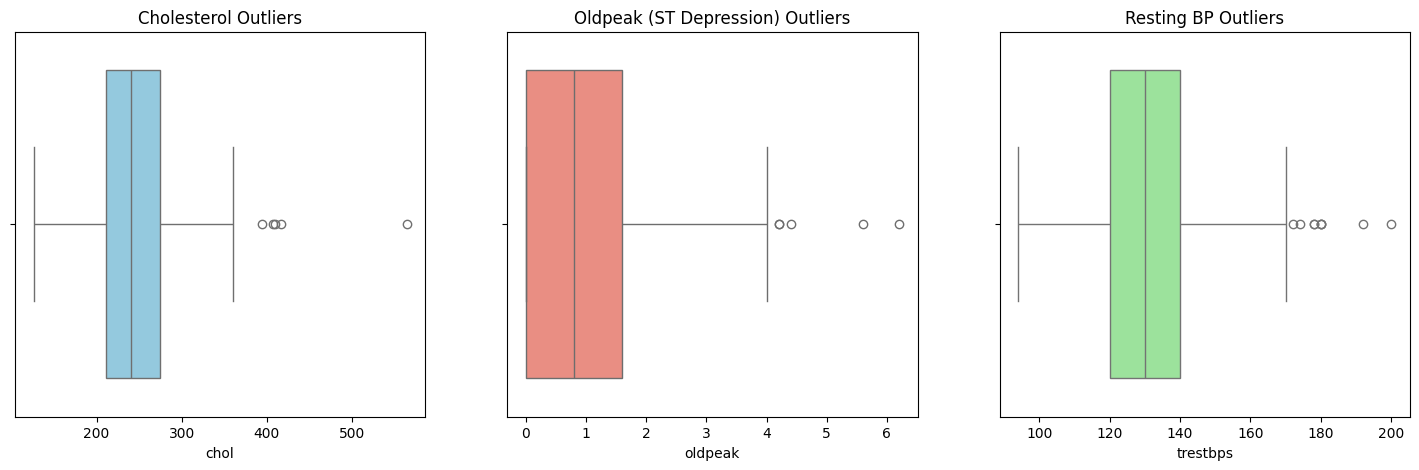

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set up the figure for key numerical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(ax=axes[0], x=X['chol'], color='skyblue').set_title('Cholesterol Outliers')
sns.boxplot(ax=axes[1], x=X['oldpeak'], color='salmon').set_title('Oldpeak (ST Depression) Outliers')
sns.boxplot(ax=axes[2], x=X['trestbps'], color='lightgreen').set_title('Resting BP Outliers')

plt.show()

**Observations:**

- Cholesterol: Several patients have levels above 400 mg/dl, including one extreme case at 564 mg/dl.

- Oldpeak: Values above 4.0 are rare and represent significant ST depression, which is a strong clinical indicator of coronary artery disease.

### 5.2 Handling Missing Values
Since we only have 6 missing values total (4 in `ca` and 2 in `thal`), mode imputation is appropriate. Both are categorical/ordinal features (ca: 0–3, thal: {3,6,7}), so the most frequent value is a sensible default. At under 2% of total records, the imputation has negligible effect on downstream distributions.

In [5]:
# Mode imputation was already applied when saving heart_disease_cleaned.csv.
# Reproduced here for reference:
X_cleaned = X.copy()
# X_cleaned['ca']   = X_cleaned['ca'].fillna(X_cleaned['ca'].mode()[0])
# X_cleaned['thal'] = X_cleaned['thal'].fillna(X_cleaned['thal'].mode()[0])

print("Missing values remaining:", X_cleaned.isnull().sum().sum())

Missing values remaining: 0


### 5.3 Save cleaned data to CSV

The cleaned dataset (303 rows, 14 columns including target) is saved as `heart_disease_cleaned.csv` and used as the canonical input for all downstream notebooks.

In [6]:
df_cleaned = pd.concat([X_cleaned, y], axis=1)
print(f"Cleaned dataset: {df_cleaned.shape[0]} rows × {df_cleaned.shape[1]} cols")
# df_cleaned.to_csv('heart_disease_cleaned.csv', index=False)  # already saved

Cleaned dataset: 303 rows × 14 cols


In [7]:
# Load the cleaned data
df = pd.read_csv('heart_disease_cleaned.csv')

# Verify the first few rows and shape
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## 6. Correlation Analysis: Identifying Clinical Drivers

Explore the relationships between our variables. A correlation matrix helps us identify which clinical markers move in tandem with the presence of heart disease.

### 6.1 Generating the Correlation Heatmap

Values closer to $1$ or $-1$ indicate a strong relationship, while values near $0$ suggest no linear correlation.

**Strongest Positive Correlations with Disease (`num`)**
- `ca` (0.52): The number of major vessels colored by fluoroscopy is the strongest positive indicator. As `ca` increases, so does the presence of heart disease.
- `thal` (0.51): The thallium stress test results show a high correlation, indicating its critical role in diagnosis.
- `oldpeak` (0.50): ST depression induced by exercise is a major diagnostic signal.
- `cp` (0.41): Chest pain type shows a significant relationship, particularly when patients report asymptomatic or non-anginal pain.

**Strongest Negative Correlations**
- `thalach` (−0.42): Maximum heart rate achieved shows a strong inverse relationship. Higher cardiovascular fitness is associated with lower disease risk.
- `thalach` vs. `age` (−0.39): Confirms that maximum heart rate capacity naturally declines with age.

**Secondary Observations**
- `exang` (0.40): Exercise-induced angina is a reliable predictor of the target variable.
- Weak Correlations: Fasting blood sugar (`fbs` at 0.06) and serum cholesterol (`chol` at 0.07) show surprisingly weak linear correlations in this dataset, suggesting they act as secondary factors rather than direct predictors.

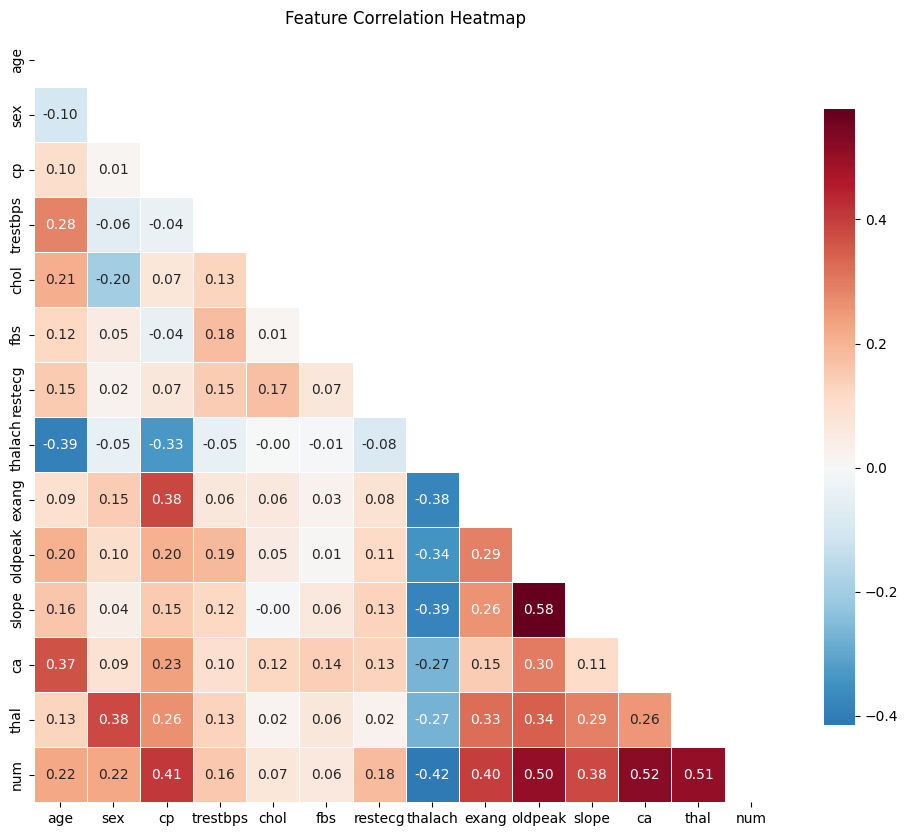

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
corr_matrix = df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(12, 10))

# Generate a mask for the upper triangle (optional, for cleaner look)
import numpy as np
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Draw the heatmap
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='RdBu_r', 
            center=0, linewidths=.5, cbar_kws={"shrink": .8})

plt.title('Feature Correlation Heatmap')
plt.show()

## 7. Visualizing Key Predictors

To better understand the distributions of our most influential features (`oldpeak` and `thalach`), we generate comparison plots across target categories.

/var/folders/bd/cy5hjy_j1w9gkcl55ywnf8w00000gn/T/ipykernel_77792/1217543759.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='num', y='thalach', data=df, palette='coolwarm')


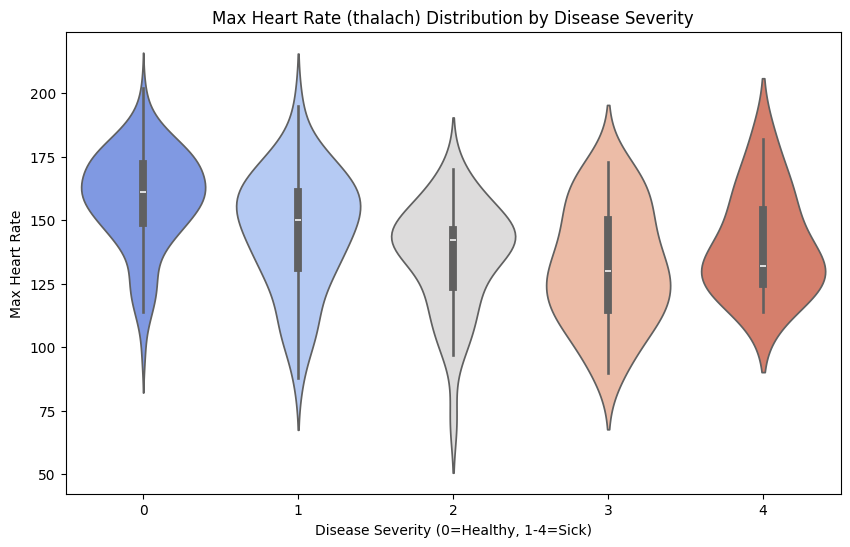

In [9]:

# Distribution of Max Heart Rate vs. Heart Disease
plt.figure(figsize=(10, 6))
sns.violinplot(x='num', y='thalach', data=df, palette='coolwarm')
plt.title('Max Heart Rate (thalach) Distribution by Disease Severity')
plt.xlabel('Disease Severity (0=Healthy, 1-4=Sick)')
plt.ylabel('Max Heart Rate')
plt.show()

### 7.1 Multivariate Analysis: Pairplot of Key Predictors

Based on the correlation heatmap, `ca`, `thal`, `oldpeak`, and `thalach` show the strongest relationships with `num`. The pairplot reveals how these variables separate healthy patients from those with heart disease:

- **Class Separation**: Healthy patients (`num=0`) form distinct, sharp peaks in the diagonal KDE plots—particularly at `oldpeak ≈ 0` and `ca = 0`. Patients with disease show broader, flatter distributions.
- **Threshold Effects**: In the `oldpeak` vs. `thalach` scatter, patients with `oldpeak > 2.0` and `thalach < 120` are almost exclusively classified with disease.
- **Ordinal Barriers**: `ca` acts as a discrete checkpoint—most healthy patients have 0 vessels colored, while even 1 vessel significantly increases disease likelihood.

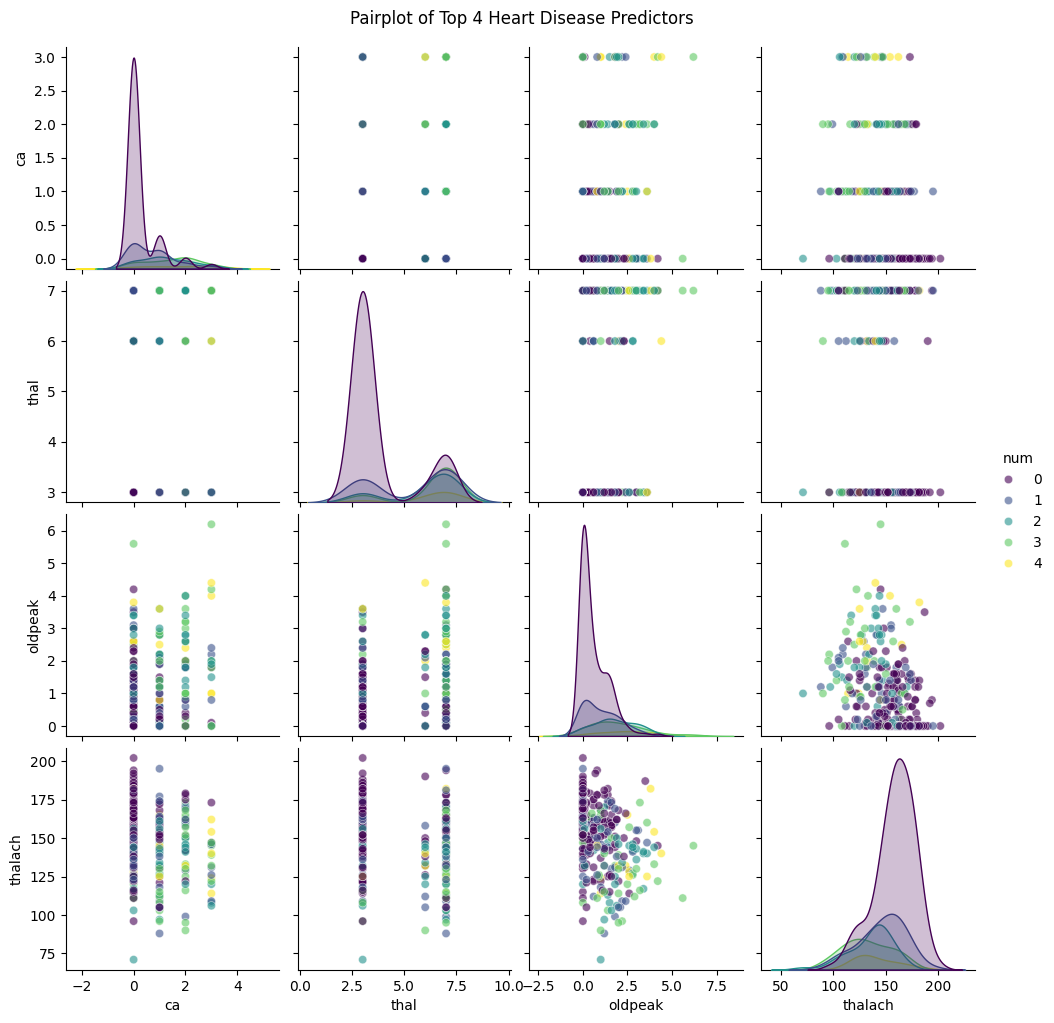

In [10]:
# Selecting the top 4 features plus the target
top_features = ['ca', 'thal', 'oldpeak', 'thalach', 'num']
df_subset = df[top_features]


sns.pairplot(df_subset, hue='num', palette='viridis', diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot of Top 4 Heart Disease Predictors', y=1.02)
plt.show()

## 8. EDA Summary

| Decision | Choice | Rationale |
|----------|--------|-----------|
| **Missing value imputation** | Mode | Only 6 values missing (<2%); both affected features (`ca`, `thal`) are categorical/ordinal |
| **Outliers retained** | Yes | Extreme values (chol=564, oldpeak=6.2) are clinically plausible and carry predictive signal |
| **Target binarisation** | `num > 0` → 1 | Collapses severity levels 1–4 into a single "disease present" class |
| **Features retained** | All 13 | No feature dropped; even weak predictors (`fbs`, `chol`) are kept for graphical model structure |

**Top 4 predictors** (by absolute correlation with `num`): `ca` (0.52), `thal` (0.51), `oldpeak` (0.50), `thalach` (−0.42).

The cleaned dataset is saved as `heart_disease_cleaned.csv` (303 rows × 14 columns) and used as the canonical input for all downstream modelling notebooks. Discretization of continuous features into ordinal bins is performed in `robustness_utils.py` and the individual model notebooks.